# Experiment C – Structured Numerical Features

## 1. Objective 

Investigate whether structured match-state features alone can predict football momentum without relying on commentary text.

## 2. Hypothesis

Cumulative match statistics and contextual game-state features contain sufficient information to model momentum dynamics.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import re
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import lightgbm
import joblib

BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

from config import *
from helper import *

DATA_PATH = BASE_DIR / "data" / "processed" / EXPERIMENT
DATA_PATH.mkdir(parents=True, exist_ok=True)
MODELS_PATH = BASE_DIR / 'models' / EXPERIMENT
REPORTS_PATH = BASE_DIR / 'reports' / 'metrics' / EXPERIMENT
FIGURE_PATH = BASE_DIR / "reports" / "figures" / EXPERIMENT

## 3. Loading Datasets

In [5]:
df = pd.read_csv("../data/raw/archive/events.csv")
ginf_df = pd.read_csv("../data/raw/archive/ginf.csv")

In [6]:
display(df.head())
display(ginf_df.head())

,id_odsp,id_event,sort_order,time,text,event_type,event_type2,side,event_team,opponent,...,player_in,player_out,shot_place,shot_outcome,is_goal,location,bodypart,assist_method,situation,fast_break
0,UFot0hit/,UFot0hit1,1,2,Attempt missed. Mladen Petric (Hamburg) left f...,1,12.0,2,Hamburg SV,Borussia Dortmund,...,NaN,NaN,6.0,2.0,0,9.0,2.0,1,1.0,0
1,UFot0hit/,UFot0hit2,2,4,"Corner, Borussia Dortmund. Conceded by Dennis...",2,NaN,1,Borussia Dortmund,Hamburg SV,...,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,0
2,UFot0hit/,UFot0hit3,3,4,"Corner, Borussia Dortmund. Conceded by Heiko ...",2,NaN,1,Borussia Dortmund,Hamburg SV,...,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,0
3,UFot0hit/,UFot0hit4,4,7,Foul by Sven Bender (Borussia Dortmund).,3,NaN,1,Borussia Dortmund,Hamburg SV,...,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,0
4,UFot0hit/,UFot0hit5,5,7,Gokhan Tore (Hamburg) wins a free kick in the ...,8,NaN,2,Hamburg SV,Borussia Dortmund,...,NaN,NaN,NaN,NaN,0,2.0,NaN,0,NaN,0


,id_odsp,link_odsp,adv_stats,date,league,season,country,ht,at,fthg,ftag,odd_h,odd_d,odd_a,odd_over,odd_under,odd_bts,odd_bts_n
0,UFot0hit/,/soccer/germany/bundesliga-2011-2012/dortmund-...,True,2011-08-05,D1,2012,germany,Borussia Dortmund,Hamburg SV,3,1,1.56,4.41,7.42,NaN,NaN,NaN,NaN
1,Aw5DflLH/,/soccer/germany/bundesliga-2011-2012/augsburg-...,True,2011-08-06,D1,2012,germany,FC Augsburg,SC Freiburg,2,2,2.36,3.60,3.40,NaN,NaN,NaN,NaN
2,bkjpaC6n/,/soccer/germany/bundesliga-2011-2012/werder-br...,True,2011-08-06,D1,2012,germany,Werder Bremen,Kaiserslautern,2,0,1.83,4.20,4.80,NaN,NaN,NaN,NaN
3,CzPV312a/,/soccer/france/ligue-1-2011-2012/paris-sg-lori...,True,2011-08-06,F1,2012,france,Paris Saint-Germain,Lorient,0,1,1.55,4.50,9.40,NaN,NaN,NaN,NaN
4,GUOdmtII/,/soccer/france/ligue-1-2011-2012/caen-valencie...,True,2011-08-06,F1,2012,france,Caen,Valenciennes,1,0,2.50,3.40,3.45,NaN,NaN,NaN,NaN


In [7]:
df.describe()

,sort_order,time,event_type,event_type2,side,shot_place,shot_outcome,is_goal,location,bodypart,assist_method,situation,fast_break
count,941009.000000,941009.000000,941009.000000,214293.000000,941009.000000,227459.000000,228498.000000,941009.000000,467067.000000,229185.000000,941009.000000,229137.000000,941009.000000
mean,53.858826,49.663663,4.326575,12.233764,1.481170,5.733693,1.926555,0.025978,6.209073,1.624831,0.264332,1.281316,0.004876
std,32.014268,26.488977,2.995313,0.468850,0.499646,3.326100,0.797055,0.159071,5.421736,0.740400,0.655501,0.709394,0.069655
min,1.000000,0.000000,1.000000,12.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,27.000000,27.000000,2.000000,12.000000,1.000000,2.000000,1.000000,0.000000,2.000000,1.000000,0.000000,1.000000,0.000000
50%,53.000000,51.000000,3.000000,12.000000,1.000000,5.000000,2.000000,0.000000,3.000000,1.000000,0.000000,1.000000,0.000000
75%,79.000000,73.000000,8.000000,12.000000,2.000000,9.000000,3.000000,0.000000,11.000000,2.000000,0.000000,1.000000,0.000000
max,180.000000,100.000000,11.000000,15.000000,2.000000,13.000000,4.000000,1.000000,19.000000,3.000000,4.000000,4.000000,1.000000


In [8]:
df.columns.to_list()

['id_odsp',
 'id_event',
 'sort_order',
 'time',
 'text',
 'event_type',
 'event_type2',
 'side',
 'event_team',
 'opponent',
 'player',
 'player2',
 'player_in',
 'player_out',
 'shot_place',
 'shot_outcome',
 'is_goal',
 'location',
 'bodypart',
 'assist_method',
 'situation',
 'fast_break']

In [9]:
df['shot_outcome'].unique()
'''
shot_outcome
1	On target
2	Off target
3	Blocked
4	Hit the bar
'''

'\nshot_outcome\n1\tOn target\n2\tOff target\n3\tBlocked\n4\tHit the bar\n'

In [10]:
df['location'].unique()
'''
1	Attacking half
2	Defensive half
3	Centre of the box
4	Left wing
5	Right wing
6	Difficult angle and long range
7	Difficult angle on the left
8	Difficult angle on the right
9	Left side of the box
10	Left side of the six yard box
11	Right side of the box
12	Right side of the six yard box
13	Very close range
14	Penalty spot
15	Outside the box
16	Long range
17	More than 35 yards
18	More than 40 yards
19	Not recorded

'''

'\n1\tAttacking half\n2\tDefensive half\n3\tCentre of the box\n4\tLeft wing\n5\tRight wing\n6\tDifficult angle and long range\n7\tDifficult angle on the left\n8\tDifficult angle on the right\n9\tLeft side of the box\n10\tLeft side of the six yard box\n11\tRight side of the box\n12\tRight side of the six yard box\n13\tVery close range\n14\tPenalty spot\n15\tOutside the box\n16\tLong range\n17\tMore than 35 yards\n18\tMore than 40 yards\n19\tNot recorded\n\n'

In [11]:
display(df['event_type'].unique())
display(df['event_type2'].unique())

''' 
event_type
0	Announcement
1	Attempt
2	Corner
3	Foul
4	Yellow card
5	Second yellow card
6	Red card
7	Substitution
8	Free kick won
9	Offside
10	Hand ball
11	Penalty conceded


event_type2
12	Key Pass    
13	Failed through ball
14	Sending off
15	Own goal
'''

array([ 1,  2,  3,  8, 10,  7,  9,  4,  6, 11,  5])

array([12., nan, 13., 14., 15.])

' \nevent_type\n0\tAnnouncement\n1\tAttempt\n2\tCorner\n3\tFoul\n4\tYellow card\n5\tSecond yellow card\n6\tRed card\n7\tSubstitution\n8\tFree kick won\n9\tOffside\n10\tHand ball\n11\tPenalty conceded\n\n\nevent_type2\n12\tKey Pass    \n13\tFailed through ball\n14\tSending off\n15\tOwn goal\n'

In [12]:
display(df['fast_break'].value_counts())
display(df['text'][df['fast_break'] == 1])

fast_break
0    936421
1      4588
Name: count, dtype: int64

43        Attempt missed. Ilkay Gundogan (Borussia Dortm...
175       Goal!  FC Augsburg 0, SC Freiburg 1. Papiss De...
198       Attempt missed. Mensur Mujdza (SC Freiburg) le...
353       Goal!  SV Werder Bremen 2, Kaiserslautern 0. M...
360       Markus Rosenberg (SV Werder Bremen) hits the r...
                                ...                        
939344    Attempt missed. Yannick Carrasco (Atletico de ...
939572    Goal!  Bologna 2, Torino 0. Blerim Dzemaili (B...
939591    Goal!  St Etienne 0, Angers 1. Mateo Pavlovic ...
939965    Attempt missed. Genki Haraguchi (Hertha Berlin...
940337    Attempt missed. Demarai Gray (Leicester City) ...
Name: text, Length: 4588, dtype: str

In [13]:
display(df['situation'].value_counts())
display(df['text'][df['situation'] == 2].head(5))

situation
1.0    193747
3.0     18226
2.0     11742
4.0      5422
Name: count, dtype: int64

136    Attempt missed. Marcel de Jong (FC Augsburg) l...
398    Goal!  Paris Saint Germain 0, Lorient 1. Julie...
531    Attempt missed. Mathieu Dossevi (Valenciennes)...
588    Attempt missed. Andreas Ottl (Hertha Berlin) r...
739    Attempt missed. Paul Baysse (Brest) header fro...
Name: text, dtype: str

## 4. Feature Engineering

We will be engineering features to capture match-state signals using cumulative & lagging window features.

### 4.1 Event Helper Functions

In [14]:
# Momentum weights
MOMENTUM_WEIGHTS = {
    1:  3, # Attempt
    2:  1, # Corner
    4: -1, # Yellow Card
    6: -3, # Red card
    9: -0.5 # Off-side
}

def get_event_weight(event):
    """
    Generate momentum weight for every event
    """
    if event.event_type == 1 and event.is_goal == 1:
        return 5
    return MOMENTUM_WEIGHTS.get(event.event_type, 0)

### 4.2 Feature generation

In [15]:
def calculate_tabular_features(match_df: pd.DataFrame, window_size: int = 5, lag_windows: int = 3):
    """
    Builds numeric feature rows per window, using only information available
    up to and including the *start* of that window — never the window's own
    events, and never future windows.

    Args:
        match_df (pd.DataFrame): Match events dataframe.
        window_size (int, optional): Rolling window of match time in minutes. Defaults to 5.
        lag_windows (int, optional): How many previous windows' momentum to include as lag features. Defaults to 3.

    """

    windows = []
    max_time = int(match_df['time'].max())

    # Counters
    home_stats = {
    "shots": 0,
    "shots_on_target": 0,
    "shots_inside_box": 0,
    "corners": 0,
    "yellow_cards": 0,
    "red_cards": 0,
    "offsides": 0,
    "subs": 0,
    "fast_breaks": 0,
    "set_piece_shots" : 0,
}
    away_stats = {
    "shots": 0,
    "shots_on_target": 0,
    "shots_inside_box": 0,
    "corners": 0,
    "yellow_cards": 0,
    "red_cards": 0,
    "offsides": 0,
    "subs": 0,
    "fast_breaks": 0,
    "set_piece_shots": 0,
}

    INSIDE_BOX_LOCATIONS = {3,9,10,11,12,13,14}# All integers correspond to locations inisde the box

    window_momentum_history = []
    home_goals = 0
    away_goals = 0

    home_last_event_time = None
    away_last_event_time = None

    for start in range(0, max_time, window_size):
        end = start + window_size

        lag_features = {
            
            f'momentum_lag_{i}': window_momentum_history[-i] if len(window_momentum_history) >= i else 0
            for i in range(1, lag_windows + 1)
        }

        # Snapshot BEFORE this window's events are folded in
        snapshot_features = {
            'home_cum_shots': home_stats['shots'],
            'away_cum_shots': away_stats['shots'],
            'home_goals': home_goals,
            'away_goals': away_goals,
            'goal_diff': home_goals - away_goals,
            'minutes_elapsed': start,
            'home_cum_shots_on_target': home_stats['shots_on_target'],
            'away_cum_shots_on_target': away_stats['shots_on_target'],
            'home_cum_shots_inside_box': home_stats['shots_inside_box'],
            'away_cum_shots_inside_box': away_stats['shots_inside_box'],
            'home_cum_sub_count': home_stats['subs'],
            'away_cum_sub_count': away_stats['subs'],
            'home_cum_corners': home_stats['corners'],
            'away_cum_corners': away_stats['corners'],
            'home_cum_yellow_cards': home_stats['yellow_cards'],
            'away_cum_yellow_cards': away_stats['yellow_cards'],
            'home_cum_red_cards': home_stats['red_cards'],
            'away_cum_red_cards': away_stats['red_cards'],
            'home_cum_offsides': home_stats['offsides'],
            'away_cum_offsides': away_stats['offsides'],
            'home_cum_fast_breaks': home_stats['fast_breaks'],
            'away_cum_fast_breaks': away_stats['fast_breaks'],
            'home_cum_set_piece_shots': home_stats['set_piece_shots'],
            'away_cum_set_piece_shots': away_stats['set_piece_shots'],
            'home_minutes_since_last_event': -1 if home_last_event_time is None else start - home_last_event_time,
            'away_minutes_since_last_event': -1 if away_last_event_time is None else start - away_last_event_time,
        }

        events = match_df[(match_df['time'] >= start) & (match_df['time'] < end)]
        home_momentum_score = 0
        away_momentum_score = 0

        for event in events.itertuples(index=False):
            weight = get_event_weight(event)
            side_stats = home_stats if event.side == 1 else away_stats

            if event.side == 1:
                home_momentum_score += weight
            else:
                away_momentum_score += weight

            # --- counter updates (shots/corners/cards/offsides) ---

            # ---  shots --- 
            if event.event_type == 1:  # 1 - Attempt
                side_stats['shots'] += 1

            # --- corners --- 
            if event.event_type == 2: # 2 - Corner
                side_stats['corners'] += 1
            
            # --- cards --- 
            if event.event_type == 4: # 4 - Yellow Card
                side_stats['yellow_cards'] += 1

            if event.event_type in {5, 6}: # 5 - 2nd Yellow / 6 - Red Card
                side_stats['red_cards'] += 1
            
            # --- offsides --- 
            if event.event_type == 9:  # 9 - Offside
                side_stats['offsides'] += 1
            
            # --- shot quality ---
            if event.event_type == 1: # Attempt
                if event.shot_outcome == 1: # 1 - on target 
                    side_stats['shots_on_target'] += 1

                if event.location in INSIDE_BOX_LOCATIONS: 
                    side_stats['shots_inside_box'] += 1

                if event.situation in {2, 3, 4}:
                    side_stats['set_piece_shots'] += 1

            # --- substitutions ---
            if event.event_type == 7:  # 7 - Substitution
                side_stats['subs'] += 1

            # --- fast break --- 
            if event.fast_break == 1:
                side_stats["fast_breaks"] += 1
            
            # --- goal --- 
            if event.is_goal == 1:
                if event.side == 1:
                    home_goals += 1
                else:
                    away_goals += 1

            # --- Remember the most recent event time for each team ---
            if event.side == 1:
                home_last_event_time = event.time
            else:
                away_last_event_time = event.time
            

        momentum = home_momentum_score - away_momentum_score
        window_momentum_history.append(momentum)
        label = 0 if momentum >= 2 else (1 if momentum <= -2 else 2)

        row = {
            'id_odsp': match_df['id_odsp'].iloc[0],
            'window_start': start,
            'window_end': end,
            'label': label,
            **lag_features,
            **snapshot_features,
            #'momentum': momentum,   # temporary debug feature
        }
        windows.append(row)

    return pd.DataFrame(windows)

### 4.3 Feature Validation

In [16]:
# Testing it on one match first
match_id = df['id_odsp'].iloc[0]
match_df = df[df['id_odsp'] == match_id]

result = calculate_tabular_features(
    match_df=match_df,
    window_size=5,
    lag_windows=3
)

# Printout
print(result.to_string())

      id_odsp  window_start  window_end  label  momentum_lag_1  momentum_lag_2  momentum_lag_3  home_cum_shots  away_cum_shots  home_goals  away_goals  goal_diff  minutes_elapsed  home_cum_shots_on_target  away_cum_shots_on_target  home_cum_shots_inside_box  away_cum_shots_inside_box  home_cum_sub_count  away_cum_sub_count  home_cum_corners  away_cum_corners  home_cum_yellow_cards  away_cum_yellow_cards  home_cum_red_cards  away_cum_red_cards  home_cum_offsides  away_cum_offsides  home_cum_fast_breaks  away_cum_fast_breaks  home_cum_set_piece_shots  away_cum_set_piece_shots  home_minutes_since_last_event  away_minutes_since_last_event
0   UFot0hit/             0           5      2             0.0             0.0             0.0               0               0           0           0          0                0                         0                         0                          0                          0                   0                   0                 0               

In [17]:
cum_cols = [c for c in result.columns if c.startswith('home_cum_') or c.startswith('away_cum_')]
for col in cum_cols:
    assert (result[col].diff().dropna() >= 0).all(), f"{col} decreased somewhere — bug"
print("All cumulative features are monotonic ✅")

All cumulative features are monotonic ✅


In [18]:
# Row 0 Check
print(result.iloc[0][cum_cols])  # should all be 0
print(result.iloc[0][['home_minutes_since_last_event', 'away_minutes_since_last_event']])  # should both be -1

home_cum_shots               0
away_cum_shots               0
home_cum_shots_on_target     0
away_cum_shots_on_target     0
home_cum_shots_inside_box    0
away_cum_shots_inside_box    0
home_cum_sub_count           0
away_cum_sub_count           0
home_cum_corners             0
away_cum_corners             0
home_cum_yellow_cards        0
away_cum_yellow_cards        0
home_cum_red_cards           0
away_cum_red_cards           0
home_cum_offsides            0
away_cum_offsides            0
home_cum_fast_breaks         0
away_cum_fast_breaks         0
home_cum_set_piece_shots     0
away_cum_set_piece_shots     0
Name: 0, dtype: object
home_minutes_since_last_event    -1
away_minutes_since_last_event    -1
Name: 0, dtype: object


In [19]:
# Ground truth: total corners taken by the home side across the whole match
true_home_corners = ((match_df['event_type'] == 2) & (match_df['side'] == 1)).sum()
true_away_corners = ((match_df['event_type'] == 2) & (match_df['side'] == 2)).sum()

# Your function's last row reflects state BEFORE the final window — add that window's own corners
last_window_events = match_df[match_df['time'] >= result.iloc[-1]['window_start']]
final_home = result.iloc[-1]['home_cum_corners'] + ((last_window_events['event_type']==2) & (last_window_events['side']==1)).sum()
final_away = result.iloc[-1]['away_cum_corners'] + ((last_window_events['event_type']==2) & (last_window_events['side']==2)).sum()

print(true_home_corners, final_home)  # should match
print(true_away_corners, final_away)  # should match

7 7
7 7


In [20]:
true_home_goals = ((match_df['is_goal'] == 1) & (match_df['side'] == 1)).sum()
true_away_goals = ((match_df['is_goal'] == 1) & (match_df['side'] == 2)).sum()

print("True:", true_home_goals, true_away_goals)
print("Model:", result.iloc[-1]['home_goals'], result.iloc[-1]['away_goals'])

True: 3 1
Model: 3 1


In [21]:
print(result['label'].value_counts(),'\n')
print(result['label'].value_counts(normalize=True))

label
0    8
2    6
1    4
Name: count, dtype: int64 

label
0    0.444444
2    0.333333
1    0.222222
Name: proportion, dtype: float64


In [22]:
result[['window_start','home_minutes_since_last_event','away_minutes_since_last_event']]

,window_start,home_minutes_since_last_event,away_minutes_since_last_event
0,0,-1,-1
1,5,1,3
2,10,3,1
3,15,1,1
4,20,1,6
5,25,5,5
6,30,1,3
7,35,2,2
8,40,1,2
9,45,2,3


In [23]:
assert (
    result["goal_diff"]
    ==
    result["home_goals"] - result["away_goals"]
).all()

print("Goal difference feature is correct ✅")

Goal difference feature is correct ✅


### 4.4 Feature Dataset Generation

In [24]:
# Appling to whole dataset
all_windows = []

for match_id in df['id_odsp'].unique():
    match_df = df[df['id_odsp'] == match_id]
    windows = calculate_tabular_features(
        match_df=match_df,
        window_size=5,
        lag_windows=3
    )
    all_windows.append(windows)

all_windows_df = pd.concat(all_windows, ignore_index=True)

print(all_windows_df['label'].value_counts())
print(all_windows_df['label'].value_counts(normalize=True))

label
0    62233
2    55357
1    47568
Name: count, dtype: int64
label
0    0.376809
2    0.335176
1    0.288015
Name: proportion, dtype: float64


In [ ]:
all_windows_df.isna().sum()

id_odsp                          0
window_start                     0
window_end                       0
label                            0
momentum_lag_1                   0
momentum_lag_2                   0
momentum_lag_3                   0
home_cum_shots                   0
away_cum_shots                   0
home_goals                       0
away_goals                       0
goal_diff                        0
minutes_elapsed                  0
home_cum_shots_on_target         0
away_cum_shots_on_target         0
home_cum_shots_inside_box        0
away_cum_shots_inside_box        0
home_cum_sub_count               0
away_cum_sub_count               0
home_cum_corners                 0
away_cum_corners                 0
home_cum_yellow_cards            0
away_cum_yellow_cards            0
home_cum_red_cards               0
away_cum_red_cards               0
home_cum_offsides                0
away_cum_offsides                0
home_cum_fast_breaks             0
away_cum_fast_breaks

In [ ]:
print("Total windows:", len(all_windows_df))
print("Unique matches:", all_windows_df["id_odsp"].nunique())
print("Original matches:", df["id_odsp"].nunique())

Total windows: 165158
Unique matches: 9074
Original matches: 9074


In [67]:
all_windows_df.describe()

,window_start,window_end,label,momentum_lag_1,momentum_lag_2,momentum_lag_3,home_cum_shots,away_cum_shots,home_goals,away_goals,...,home_cum_red_cards,away_cum_red_cards,home_cum_offsides,away_cum_offsides,home_cum_fast_breaks,away_cum_fast_breaks,home_cum_set_piece_shots,away_cum_set_piece_shots,home_minutes_since_last_event,away_minutes_since_last_event
count,165158.000000,165158.000000,165158.000000,165158.000000,165158.000000,165158.000000,165158.000000,165158.000000,165158.000000,165158.000000,...,165158.000000,165158.000000,165158.000000,165158.000000,165158.000000,165158.000000,165158.000000,165158.000000,165158.000000,165158.000000
mean,43.029160,48.029160,0.958367,0.537955,0.504838,0.474691,6.038751,4.764432,0.647737,0.469357,...,0.016717,0.022257,1.150274,1.034337,0.098990,0.089569,0.973577,0.703708,2.011335,2.141798
std,26.278142,26.278142,0.842767,4.477373,4.333011,4.189492,5.008965,4.141657,0.934625,0.770184,...,0.131613,0.150366,1.407866,1.324494,0.342559,0.323574,1.194672,0.973743,1.823172,1.986370
min,0.000000,5.000000,0.000000,-27.000000,-27.000000,-27.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000
25%,20.000000,25.000000,0.000000,-2.000000,-2.000000,-1.000000,2.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,45.000000,50.000000,1.000000,0.000000,0.000000,0.000000,5.000000,4.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,2.000000,2.000000
75%,65.000000,70.000000,2.000000,3.000000,3.000000,3.000000,9.000000,7.000000,1.000000,1.000000,...,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,2.000000,1.000000,3.000000,3.000000
max,95.000000,100.000000,2.000000,28.000000,28.000000,28.000000,42.000000,35.000000,9.000000,8.000000,...,2.000000,2.000000,14.000000,14.000000,4.000000,4.000000,11.000000,8.000000,64.000000,61.000000


In [ ]:
all_windows_df.to_csv(DATA_PATH / "experiment_c_features.csv", index=False)

## 5. Train / Validation / Test Splits

The dataset is split into training, validation, and test sets using match identifiers (`id_odsp`). Splitting at the match level ensures that events from the same football match do not appear in multiple data partitions, preventing data leakage during model evaluation.

### 5.1 Match Level Splits

In [72]:
# Get unique ids from the dataframe
unique_ids = all_windows_df['id_odsp'].unique()

rng = np.random.default_rng(42)
shuffled_ids = rng.permutation(unique_ids)

n = len(shuffled_ids)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_ids = shuffled_ids[:train_end]
val_ids = shuffled_ids[train_end:val_end]
test_ids = shuffled_ids[val_end:]

### 5.2 Verification

In [73]:
train_df = all_windows_df[all_windows_df['id_odsp'].isin(train_ids)]
val_df = all_windows_df[all_windows_df['id_odsp'].isin(val_ids)]
test_df = all_windows_df[all_windows_df['id_odsp'].isin(test_ids)]

print(f'The shape of Train split :{train_df.shape}')
print(f'The shape of Val split :{val_df.shape}')
print(f'The shape of Test split :{test_df.shape}')

The shape of Train split :(115597, 33)
The shape of Val split :(24779, 33)
The shape of Test split :(24782, 33)


In [74]:
print("Total windows:", len(all_windows_df))
print("Unique matches:", all_windows_df["id_odsp"].nunique())
print("Original matches:", df["id_odsp"].nunique())

Total windows: 165158
Unique matches: 9074
Original matches: 9074


In [ ]:
# Check if the datasets are separated for same match split.

a_train_ids = set(pd.read_csv(BASE_DIR / 'data' / 'processed' / 'exp_a_prefix' / 'train.csv')['id_odsp'].unique())
a_val_ids = set(pd.read_csv(BASE_DIR / 'data' / 'processed' / 'exp_a_prefix' / 'val.csv')['id_odsp'].unique())
a_test_ids = set(pd.read_csv(BASE_DIR / 'data' / 'processed' / 'exp_a_prefix' / 'test.csv')['id_odsp'].unique())

c_train_ids = set(train_df['id_odsp'].unique())
c_val_ids = set(val_df['id_odsp'].unique())
c_test_ids = set(test_df['id_odsp'].unique())

print("Train match:", a_train_ids == c_train_ids)
print("Val match:", a_val_ids == c_val_ids)
print("Test match:", a_test_ids == c_test_ids)

Train match: True
Val match: True
Test match: True


### 5.3 Saving Processed Datasets

In [75]:
train_df.to_csv( DATA_PATH / 'train.csv', index=False)
val_df.to_csv( DATA_PATH / 'val.csv', index=False)
test_df.to_csv( DATA_PATH / 'test.csv', index=False)

## 6. Model Training

### 6.1 Baseline: Logistic Regression

In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Feature columns
drop_cols = ['id_odsp', 'window_start', 'window_end', 'label']
feature_cols = [c for c in train_df.columns if c not in drop_cols]

X_train, y_train = train_df[feature_cols], train_df['label']
X_val, y_val = val_df[feature_cols], val_df['label']
X_test, y_test = test_df[feature_cols], test_df['label']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
logreg.fit(X_train_scaled, y_train)

val_preds = logreg.predict(X_val_scaled)
print("Logistic Regression — Validation")
print(classification_report(y_val, val_preds, target_names=CLASS_NAMES))

Logistic Regression — Validation
               precision    recall  f1-score   support

Home Dominant       0.45      0.43      0.44      9431
Away Dominant       0.35      0.40      0.38      6990
     Balanced       0.38      0.36      0.37      8358

     accuracy                           0.40     24779
    macro avg       0.39      0.40      0.39     24779
 weighted avg       0.40      0.40      0.40     24779



In [91]:
coef_df = pd.DataFrame(
    logreg.coef_.T,
    index=feature_cols,
    columns=CLASS_NAMES
)
display(coef_df)

,Home Dominant,Away Dominant,Balanced
momentum_lag_1,0.024380,-0.022890,-0.001490
momentum_lag_2,0.004068,-0.003647,-0.000422
momentum_lag_3,0.014310,-0.013437,-0.000873
home_cum_shots,0.163495,-0.094309,-0.069186
away_cum_shots,-0.082924,0.148414,-0.065491
home_goals,-0.045821,0.033411,0.012410
away_goals,0.021955,-0.022117,0.000162
goal_diff,-0.053784,0.043497,0.010287
minutes_elapsed,-0.005679,0.037990,-0.032311
home_cum_shots_on_target,0.009534,-0.014011,0.004477


### 6.2 LightGBM

In [94]:
import lightgbm as lgb

lgbm = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    class_weight='balanced',
    random_state=42,
    n_estimators=200
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='multi_logloss',
    callbacks=[lgb.early_stopping(stopping_rounds=20)]
)

val_preds = lgbm.predict(X_val)
print("LightGBM — Validation")
print(classification_report(y_val, val_preds, target_names=CLASS_NAMES))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002479 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 630
[LightGBM] [Info] Number of data points in the train set: 115597, number of used features: 29
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[38]	valid_0's multi_logloss: 1.08148
LightGBM — Validation
               precision    recall  f1-score   support

Home Dominant       0.44      0.45      0.45      9431
Away Dominant       0.35      0.46      0.40      6990
     Balanced       0.39      0.27      0.32      8358

     accuracy                           0.39     24779
    macro avg       0.39      0.40      0.39     247

In [95]:
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": lgbm.feature_importances_
}).sort_values("importance", ascending=False)
display(importance)

,feature,importance
3,home_cum_shots,293
2,momentum_lag_3,273
1,momentum_lag_2,259
4,away_cum_shots,256
0,momentum_lag_1,250
7,goal_diff,199
8,minutes_elapsed,163
15,home_cum_corners,151
16,away_cum_corners,135
11,home_cum_shots_inside_box,109


## 7. Test Evaluation

### 7.1 Baseline: Logistic Regression

In [115]:
REPORTS_PATH = BASE_DIR / 'reports' / 'metrics' / EXPERIMENT

logreg_test_preds = logreg.predict(X_test_scaled)

logreg_report = classification_report(
    y_test, 
    logreg_test_preds, 
    target_names=CLASS_NAMES,
    output_dict=True
    )

with open( REPORTS_PATH / "logistic_regression_classification_report.txt", "w") as f:
    json.dump(logreg_report, f, indent=4)

print("Logistic Regression — Test Evaluation")
print(
    classification_report(
    y_test,
    logreg_test_preds,
    target_names=CLASS_NAMES
))

Logistic Regression — Test Evaluation
               precision    recall  f1-score   support

Home Dominant       0.45      0.43      0.44      9492
Away Dominant       0.36      0.40      0.38      7095
     Balanced       0.37      0.36      0.37      8195

     accuracy                           0.40     24782
    macro avg       0.39      0.40      0.39     24782
 weighted avg       0.40      0.40      0.40     24782



### 7.2 LightGBM

In [113]:
lgb_test_preds = lgbm.predict(X_test)

lgb_report = classification_report(
    y_test,
    lgb_test_preds,
    target_names=CLASS_NAMES,
    output_dict=True
)

with open(REPORTS_PATH / "lightgbm_classification_report.txt", "w") as f:
    json.dump(lgb_report, f, indent=4)

print("LightGBM — Test Evaluation")
print(classification_report(
    y_test,
    lgb_test_preds,
    target_names=CLASS_NAMES
))

LightGBM — Test Evaluation
               precision    recall  f1-score   support

Home Dominant       0.45      0.46      0.45      9492
Away Dominant       0.35      0.45      0.39      7095
     Balanced       0.38      0.27      0.32      8195

     accuracy                           0.40     24782
    macro avg       0.39      0.40      0.39     24782
 weighted avg       0.40      0.40      0.39     24782



## 8. Comparison 

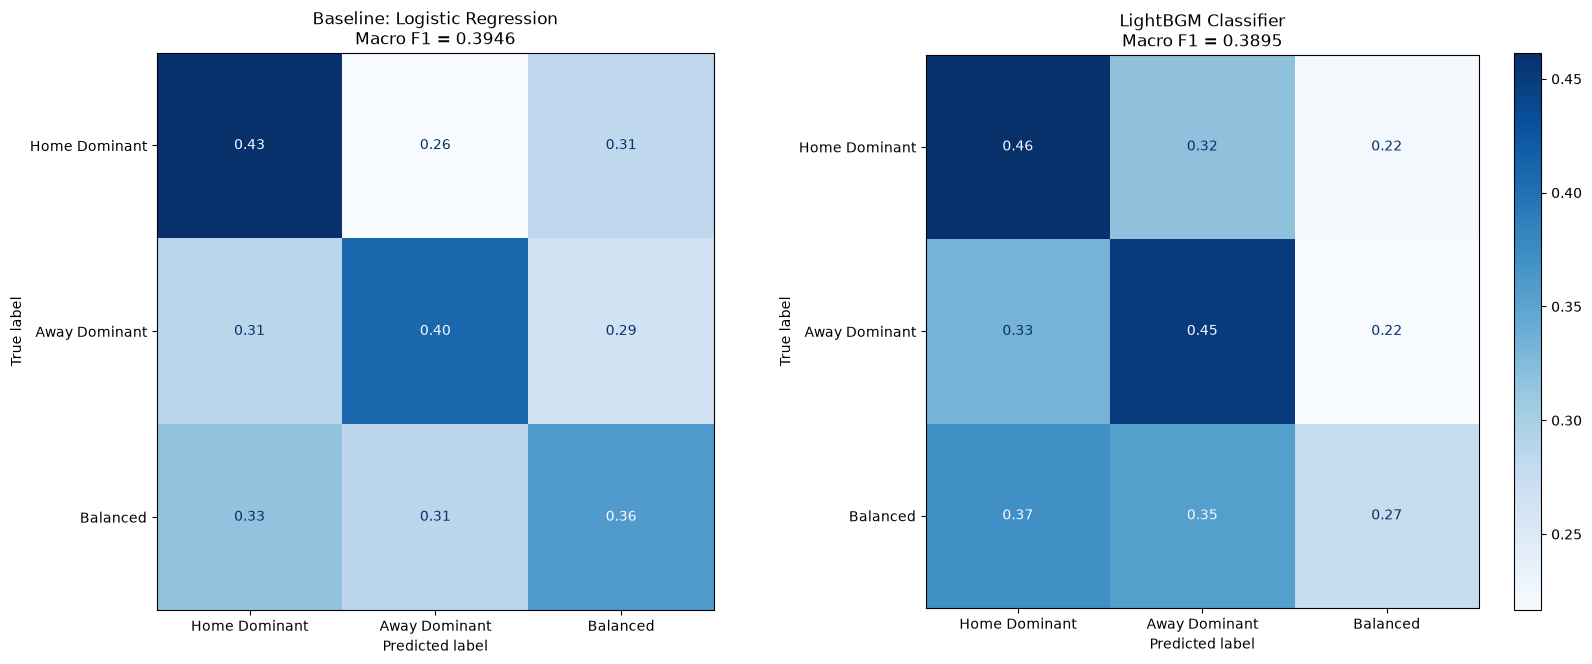

In [118]:
plot_confusion_matrices(
    model1_true=y_test,
    model1_preds=logreg_test_preds,
    model2_true=y_test,
    model2_preds=lgb_test_preds,
    display_labels=CLASS_NAMES,
    model1_name="Baseline: Logistic Regression",
    model2_name="LightBGM Classifier",
    save_dir=FIGURE_PATH,
    filename='logreg_vs_lightgbm_cm.png'
)

In [119]:
summary_exp_c = compare_classification_reports(
    logreg_report,
    lgb_report,
    names=("Baseline: Logistic Regression", "LightGBM Classifier")
)

display(
    summary_exp_c.style.format({
        "Baseline: Logistic Regression" : "{:.4f}",
        "LightGBM Classifier": "{:.4f}",
        "Δ": "{:+.4f}",
    })
    .background_gradient(subset=["Δ"], cmap="RdYlGn")
    .hide(axis="index")
)

Metric,Baseline: Logistic Regression,LightGBM Classifier,Δ
Accuracy,0.3973,0.3965,-0.0008
Macro Precision,0.3946,0.3936,-0.0009
Macro Recall,0.3954,0.3955,+0.0001
Macro F1,0.3946,0.3895,-0.0051
Weighted F1,0.3979,0.3927,-0.0052
Home Dominant F1,0.4425,0.4547,+0.0122
Away Dominant F1,0.3758,0.3943,+0.0186
Balanced F1,0.3654,0.3195,-0.0459


### Discussion 

Logistic Regression and LightGBM achieved nearly identical aggregate performance (Macro F1: 0.3946 vs. 0.3895), despite LightGBM's ability to model non-linear feature interactions. This near-equivalence is informative: if the engineered features contained substantial exploitable non-linear structure, a meaningful improvement from LightGBM over the linear baseline would be expected. Instead, although per-class behaviour differed, the LightGBM achieved higher recall on the Away Dominant class (0.46 vs. 0.40) while performing substantially worse on the Balanced class (F1: 0.32 vs. 0.37), the overall performance of the two models remained remarkably similar. These findings suggest that, for the current feature set, increasing model complexity alone does not substantially improve predictive performance. This is consistent with the hypothesis that the limiting factor is the information content of the engineered numerical features rather than the expressive capacity of the learning algorithm.

## 9. Comparing with Experiment A

In [103]:
# Load Predictions & Labels fromn Experiment - A
exp_a_preds = np.load(BASE_DIR / 'reports' / 'metrics' / 'exp_a_prefix' / 'bert_momentum_preds.npy')
exp_a_labels = np.load(BASE_DIR / 'reports' / 'metrics' / 'exp_a_prefix' / 'bert_momentum_labels.npy')

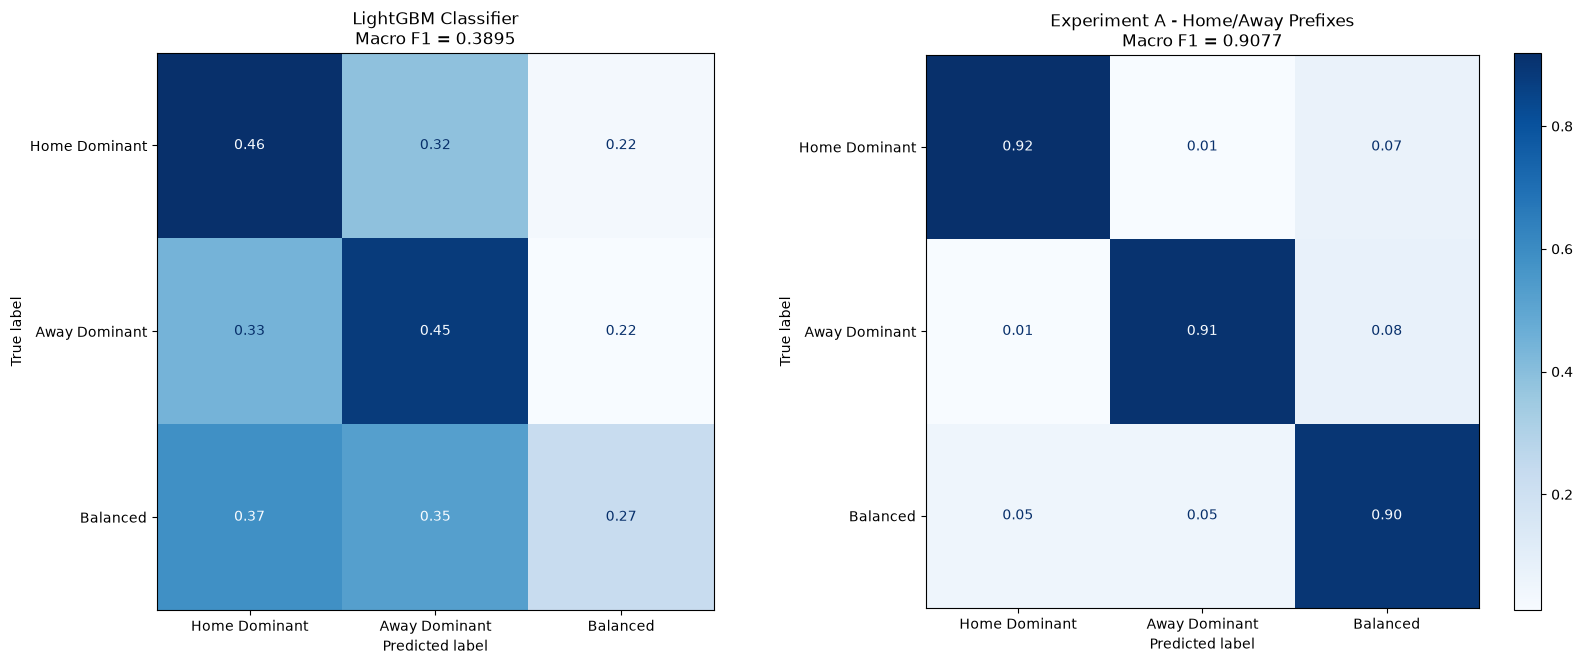

In [120]:
plot_confusion_matrices(
    model1_true=y_test,
    model1_preds=lgb_test_preds,
    model2_true=exp_a_labels,
    model2_preds=exp_a_preds,
    display_labels=CLASS_NAMES,
    model1_name="LightGBM Classifier",
    model2_name="Experiment A - Home/Away Prefixes",
    save_dir=FIGURE_PATH,
    filename="experiment_c_comparison_cm.png",
)

In [ ]:
report_a = load_report(BASE_DIR / 'reports' /'metrics' / 'exp_a_prefix' /"bert_momentum_metrics.txt")
lgb_report = load_report(REPORTS_PATH / "lightgbm_classification_report.txt" )

summary = compare_classification_reports(
    report_a,
    lgb_report,
    names=("Experiment A - Prefix", "LightGBM")
)

display(
    summary.style
    .format({
        "Experiment A - Prefix": "{:.4f}",
        "LightGBM": "{:.4f}",
        "Δ": "{:+.4f}",
    })
    .background_gradient(subset=["Δ"], cmap="RdYlGn")
    .hide(axis="index")
)

Metric,Experiment A - Prefix,LightGBM,Δ
Accuracy,0.9086,0.3965,-0.5121
Macro Precision,0.9081,0.3936,-0.5145
Macro Recall,0.9078,0.3955,-0.5123
Macro F1,0.9077,0.3895,-0.5182
Weighted F1,0.9090,0.3927,-0.5163
Home Dominant F1,0.9316,0.4547,-0.4769
Away Dominant F1,0.9174,0.3943,-0.5231
Balanced F1,0.8742,0.3195,-0.5547


### Discussion

Experiment A substantially outperformed the strongest tabular baseline, with Macro F1 increasing from 0.3895 to 0.9077. The confusion matrices further illustrate the difference: the DistilBERT model consistently distinguished all three momentum states with high accuracy, whereas the LightGBM classifier frequently confused Balanced windows with both Home Dominant and Away Dominant classes. This large performance gap suggests that the sequential event descriptions contain considerably richer predictive information than the engineered cumulative numerical features alone. While Experiment C demonstrates that structured match statistics provide some predictive signal, they capture only a fraction of the information available in the textual event sequence. These findings indicate that preserving the temporal order and contextual relationships between events is critical for accurate football momentum prediction.

## 10. Discussion

Experiment C investigated whether engineered structured match-state features could independently predict football momentum. The experimental results show that, although these features contain useful predictive information, they are substantially less informative than the sequential textual event descriptions used by Experiment A.

Experiment A substantially outperformed the strongest tabular model. The confusion matrices show that the tabular models struggled to identify the Balanced game state, whereas DistilBERT classified all three momentum states with consistently high accuracy.   

This is reinforced by the feature importance results: the simplest cumulative features (raw shot counts, lagged momentum) dominated over the more granular engineered features (shot quality, set-piece origin, substitution timing), suggesting the limitation appears not to be which statistics were aggregated, but that aggregation itself discards the sequential and contextual detail the label depends on. This suggests that increasing the sophistication of engineered cumulative statistics alone is unlikely to close the large performance gap observed between the tabular and text-based approaches.

A likely explanation is that cumulative features summarize the overall match state but discard the sequence, timing, and interactions between events. In contrast, the textual event stream preserves this context, allowing DistilBERT to learn richer representations of momentum. This suggests that the performance difference is primarily driven by differences in information representation rather than model complexity alone.

An important finding from Experiment C is that both Logistic Regression and LightGBM converged to almost identical overall performance. This indicates that the limitation is unlikely to stem from insufficient model capacity. Instead, the results suggest that the predictive information contained within the engineered numerical features has largely been exhausted, motivating the exploration of richer representations that preserve temporal event context in the subsequent hybrid experiment. 

## 11. Conclusion 

Experiment A substantially outperformed the strongest tabular baseline, demonstrating that textual event sequences provide far richer information for football momentum prediction than engineered cumulative numerical features alone. These findings suggest that preserving temporal order and contextual relationships between events is critical for accurately modelling momentum, and that increasing model complexity on the current tabular feature set does not compensate for the information lost during feature aggregation.

Given this, Experiment D will test whether these structured features can still contribute complementary signal when fused with Experiment A's text representation, rather than serving as a standalone predictor, making it a meaningfully different question than whether they work in isolation.